# Corregir Imputación Incorrecta

En este paso se convierten en 0 aquellos valores antes de la fecha de cosecha que debieron permanecer en 0 debido a que aún no se habían recolectado frutos

In [1]:
import pandas as pd

df = pd.read_csv("../BaseDatos/df_imputed_with_original_V2.csv")
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
#Volver a cero variables de productividad antes de 2 de octubre (inicio de registros)
prod_vars = ['Number of Harvested Fruits', 
             'Weight of Harvested Fruits (Kg)','Fruit Height (mm)', 'Fruit Diameter (mm)']
cutoff_date = pd.to_datetime('2024-10-02')
for var in prod_vars:
    df.loc[df['Date'] < cutoff_date, var] = 0
#mostrar columna de 'Number of Harvested Fruits' para verificar
#print(df[['Date', 'Number of Harvested Fruits']].head(50))
df.drop(columns=['Date'], inplace=True)
display(df.head())
df.to_csv("../BaseDatos/df_imputed_corrected_V2.csv", index=False)

,Plant_Height (cm),Chlorophyll (SPAD),Number of Flowers,Number of Harvested Fruits,Weight of Harvested Fruits (Kg),Fruit Height (mm),Sap pH,Sap K (ppm),Sap Ca (ppm),Sap Na (ppm),...,Air_sensor_Humidity[%RH],7in1_Conductivity[mS/cm],Pynamometer_Radiation[W/m2],Nitrogen,Phosphorus,Potassium,Year,Month,Day,Treatment_Num
0,21.5,34.8,13.0,0.0,0.0,0.0,5.5000,3455.0,748.5,49.05,...,53.1,0.183,428.0,2.0,2.0,2.0,2024.0,7.0,30.0,27.0
1,22.0,37.5,9.9,0.0,0.0,0.0,5.4860,3055.0,364.1,48.65,...,51.6,0.309,295.0,2.0,1.0,1.0,2024.0,7.0,30.0,24.0
2,18.0,37.2,15.2,0.0,0.0,0.0,5.5880,3170.0,283.6,42.40,...,51.8,0.118,383.0,0.0,0.0,1.0,2024.0,7.0,30.0,4.0
3,18.5,39.5,13.6,0.0,0.0,0.0,5.4345,3260.0,217.4,57.50,...,53.8,0.278,464.0,1.0,1.0,1.0,2024.0,7.0,30.0,15.0
4,22.0,40.1,10.9,0.0,0.0,0.0,5.8920,3080.0,326.0,50.20,...,51.9,0.371,508.0,0.0,2.0,2.0,2024.0,7.0,30.0,9.0


## Distribución de Datos según el tipo de Fertilizante

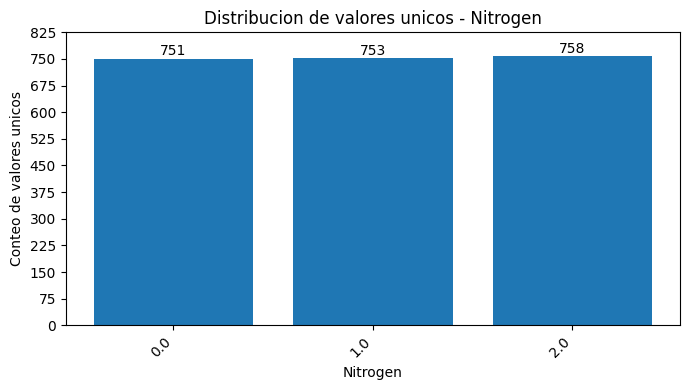

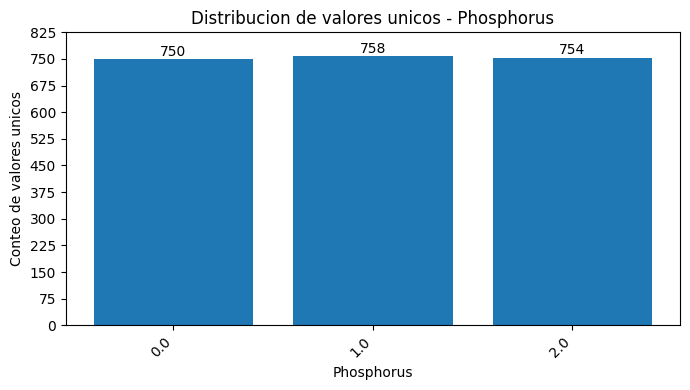

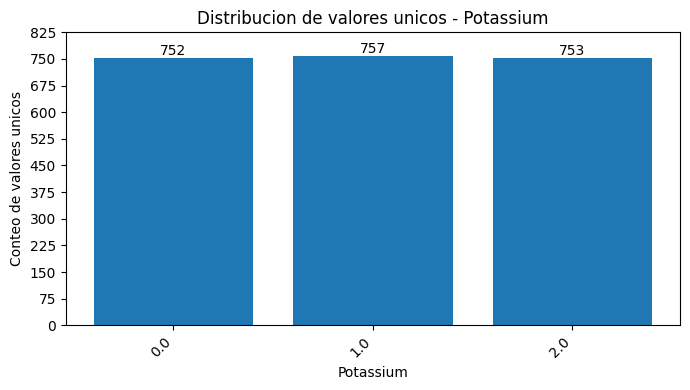

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# leer df
df = pd.read_csv("../BaseDatos/df_imputed_with_original_V2.csv")

cols = ["Nitrogen", "Phosphorus", "Potassium"]

for col in cols:
    counts = df[col].value_counts(dropna=False).sort_index()

    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(col)
    for i, v in enumerate(counts.values):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom')
    plt.ylabel("Conteo de valores unicos")
    plt.yticks(range(0, max(counts.values) + 100, max(1, max(counts.values) // 10)))
    plt.title(f"Distribucion de valores unicos - {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()